In [1]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd

In [2]:
# Load the image
with rasterio.open("../src/trimmed-sentinel-2-data/trimmed_S2A_17TLJ_20190714_0_L2A_TCI.tif") as src:
    image = src.read()
    height, width = image.shape[1], image.shape[2]
    transform = src.transform
    crs = src.crs

# Prepare image for processing - reshape and normalize
img = np.transpose(image, (1, 2, 0))
img_8bit = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

In [3]:
# Create grayscale image - dimensionality reduction, we just need intensity not the color difference
gray = cv2.cvtColor(img_8bit, cv2.COLOR_RGB2GRAY)

# Apply moderate bilateral filter - reduces noise while preserving important edge transitions, 
# helps the Canny algorithm focus on meaningful boundaries
filtered = cv2.bilateralFilter(gray, 5, 75, 75)

# Apply Canny edge detection with moderate thresholds -
# the lower value (40) is high enough to reject noise but low enough to detect subtle field 
# boundaries, while the upper value (110) ensures only significant edges are captured
edges = cv2.Canny(filtered, 40, 110)

# Apply minimal morphological operations - helps connect small breaks in the edge detection
kernel = np.ones((2, 2), np.uint8)
closed_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=1)

In [4]:
# Find contours with hierarchy information - use RETR_TREE to get the hierarchy -
contours, hierarchy = cv2.findContours(closed_edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Get hierarchy in the right format
if hierarchy is not None:
    hierarchy = hierarchy[0]  # OpenCV returns hierarchy as a nested structure
else:
    # If no hierarchy found, just process all contours
    hierarchy = np.zeros((len(contours), 4), dtype=np.int32) - 1

In [5]:
# Filter contours and identify parent-child relationships - 
# captures parent-child relationships between contours, allowing the
# algorithm to identify fields within fields

# filter out contours based purely on area
# if valid contour has a parent, mark the parent to be ignored
# count the individual fields within a larger boundary, not the boundary itself


# Define min and max area for valid contours
min_area = 75
max_area = height * width * 0.12

# Create a set to store indices of outer contours that contain other valid contours
outer_contours_to_ignore = set()

# First, identify valid contours by area
valid_contours = []
valid_indices = []

for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)
    if min_area < area < max_area:
        valid_contours.append(cnt)
        valid_indices.append(i)

# Then, for each valid contour, check if it has a parent
# If the parent is also valid, mark the parent to be ignored
for i, idx in enumerate(valid_indices):
    # Check if this contour has a parent
    parent_idx = hierarchy[idx][3]
    
    # If parent exists and is also a valid contour, mark the parent to be ignored
    if parent_idx != -1 and parent_idx in valid_indices:
        outer_contours_to_ignore.add(parent_idx)


In [6]:
# Create segmentation map with integer IDs for each field, all 0 for now
segmentation = np.zeros((height, width), dtype=np.int32)

# Keep only contours that are not marked to be ignored
field_id = 1  # Start field IDs at 1 (0 is background)

# filter out linear features like roads
for i, idx in enumerate(valid_indices):
    if idx not in outer_contours_to_ignore:
        cnt = contours[idx]
        
        # Apply additional road filtering
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)
        
        if perimeter <= 0:
            continue
            
        rect = cv2.minAreaRect(cnt)
        box_width, box_height = rect[1]
        
        if min(box_width, box_height) <= 0:
            continue
            
        # Aspect ratio of the bounding rectangle (ratio of longer side to shorter side)
        aspect_ratio = max(box_width, box_height) / min(box_width, box_height)
        # Minimum bounding rectangle dimensions (skipping contours with zero dimensions)
        rect_area = box_width * box_height
        # Rectangularity (how well the contour fills its minimum bounding rectangle)
        rectangularity = area / rect_area if rect_area > 0 else 0
        
        # Only filter out obvious roads - very rectangular and nearly square
        if not (rectangularity > 0.9 and 0.9 < aspect_ratio < 1.1):
            # Fill the contour with the field_id
            cv2.drawContours(segmentation, [cnt], 0, field_id, -1)
            field_id += 1

In [7]:
# # Now convert segmentation to DataFrame
# # Generate coordinate grids
# y_coords, x_coords = np.mgrid[0:height, 0:width]

# # Create a DataFrame with x, y coordinates and field_id
# df_model_output = pd.DataFrame({
#     'x': x_coords.flatten(),
#     'y': y_coords.flatten(),
#     'field_id': segmentation.flatten()
# })

# # Filter out background (field_id == 0) if not needed
# df_model_output = df_model_output[df_model_output['field_id'] > 0]

# # Save the DataFrame to a CSV file
# df_model_output.to_csv("contour-based-output.csv", index=False)

# The df_model_output can now be used with the accuracy calculator
# noise_results = compute_field_noise(df_model_output, df_truth, bin_size=20)

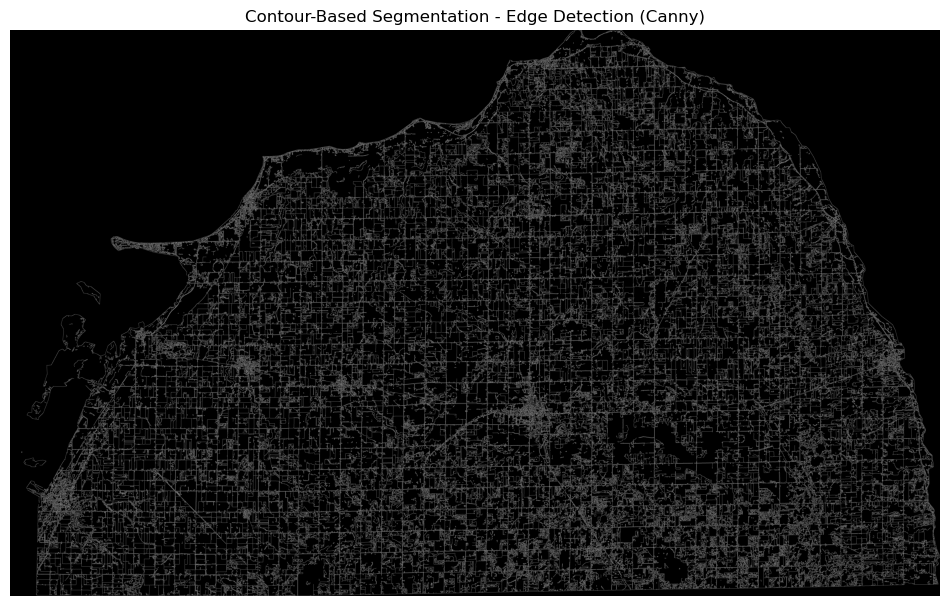

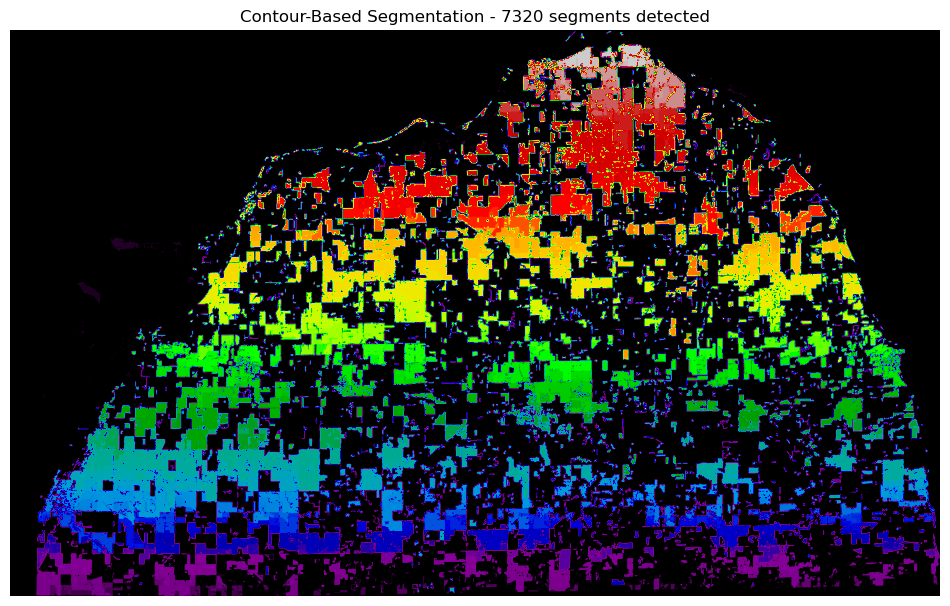

In [8]:
# Visualize the edge detection and segmentation results side by side
plt.figure(figsize=(12, 12))
plt.imshow(edges, cmap='gray')
plt.title("Contour-Based Segmentation - Edge Detection (Canny)")
plt.axis('off')
plt.show()

# Display segmentation map with a colormap for better distinction
plt.figure(figsize=(12, 12))
plt.imshow(segmentation, cmap='nipy_spectral')
plt.title(f"Contour-Based Segmentation - {field_id-1} segments detected")
plt.axis('off')
plt.show()

In [9]:
# # Create boundary image
# boundary_image = img_8bit.copy()
# # We need to collect the filtered contours that were actually used
# used_contours = []
# for i, idx in enumerate(valid_indices):
#     if idx not in outer_contours_to_ignore:
#         cnt = contours[idx]
#         area = cv2.contourArea(cnt)
#         perimeter = cv2.arcLength(cnt, True) if area > 0 else 0
        
#         if perimeter <= 0:
#             continue
            
#         rect = cv2.minAreaRect(cnt)
#         box_width, box_height = rect[1]
        
#         if min(box_width, box_height) <= 0:
#             continue
            
#         aspect_ratio = max(box_width, box_height) / min(box_width, box_height)
#         rect_area = box_width * box_height
#         rectangularity = area / rect_area if rect_area > 0 else 0
        
#         # Only filter out obvious roads
#         if not (rectangularity > 0.9 and 0.9 < aspect_ratio < 1.1):
#             used_contours.append(cnt)

# cv2.drawContours(boundary_image, used_contours, -1, (0, 255, 0), 1)
# plt.figure(figsize=(12, 12))
# plt.imshow(cv2.cvtColor(boundary_image, cv2.COLOR_BGR2RGB))
# plt.title(f"Contour-Based Segmentation - Boundary Detection ({len(used_contours)} contours)")
# plt.axis('off')
# plt.show()